In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt

In [2]:
base_folder = r"/storage/alplakes_test/lucerne_100m_2025"
ke_folder = os.path.join(base_folder, "outputs_swirl", "ke_eddy")
wind_folder = os.path.join(base_folder, 'wind_analysis')

# Import dataset

In [3]:
E_wind_hourly = xr.open_dataarray(os.path.join(wind_folder, 'E_input_wind.nc'))

In [4]:
eddy_ke = pd.read_csv(os.path.join(ke_folder, "ke_eddies.csv"), index_col=1).drop(columns=["Unnamed: 0"])
lake_ke = pd.read_csv(os.path.join(ke_folder, "ke_lake.csv"), index_col=1).drop(columns=["Unnamed: 0"])

In [5]:
E_wind_hourly = E_wind_hourly.sel(time=E_wind_hourly.time >= np.datetime64('2025-03-01'))
eddy_ke = eddy_ke.loc[eddy_ke.index >= '2025-03-01']
lake_ke = lake_ke.loc[lake_ke.index >= '2025-03-01']


# Energy timeseries

In [68]:
rolling_window = 24

In [69]:
nb_cells = 11352
total_area = nb_cells * 100**2

In [70]:
E_wind_MJ = nb_cells * E_wind_hourly / 1e6 # 11352 = nb of cells. To delete once E_wind_hourly is corrected
E_wind_MJ_rolling = E_wind_MJ.rolling(time=rolling_window, min_periods=1).sum()

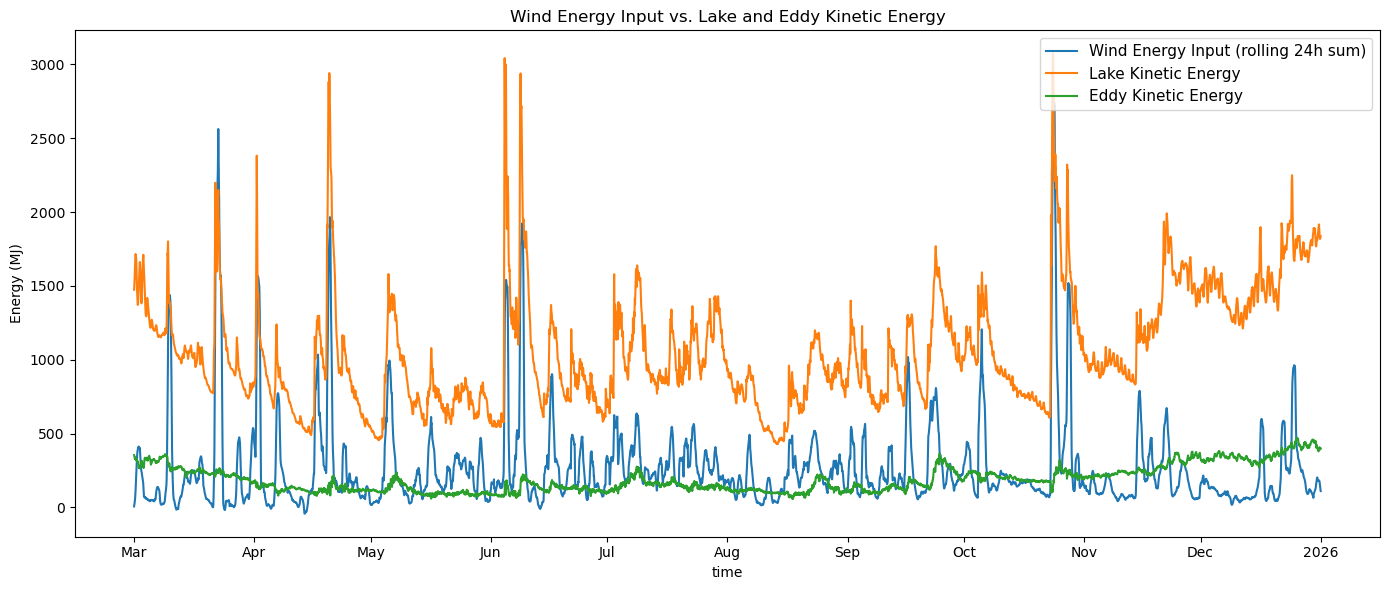

In [71]:
fig, ax = plt.subplots(figsize=(14, 6))
E_wind_MJ_rolling.plot(ax=ax, label=f'Wind Energy Input (rolling {rolling_window}h sum)')
ax.plot(pd.to_datetime(lake_ke.index), lake_ke['kinetic_energy_[MJ]'], label='Lake Kinetic Energy')
ax.plot(pd.to_datetime(eddy_ke.index), eddy_ke['kinetic_energy_eddy_[MJ]'], label='Eddy Kinetic Energy')
ax.legend(fontsize=11, loc='upper right')
ax.set_ylabel('Energy (MJ)')
ax.set_title('Wind Energy Input vs. Lake and Eddy Kinetic Energy')
plt.tight_layout()
plt.show()


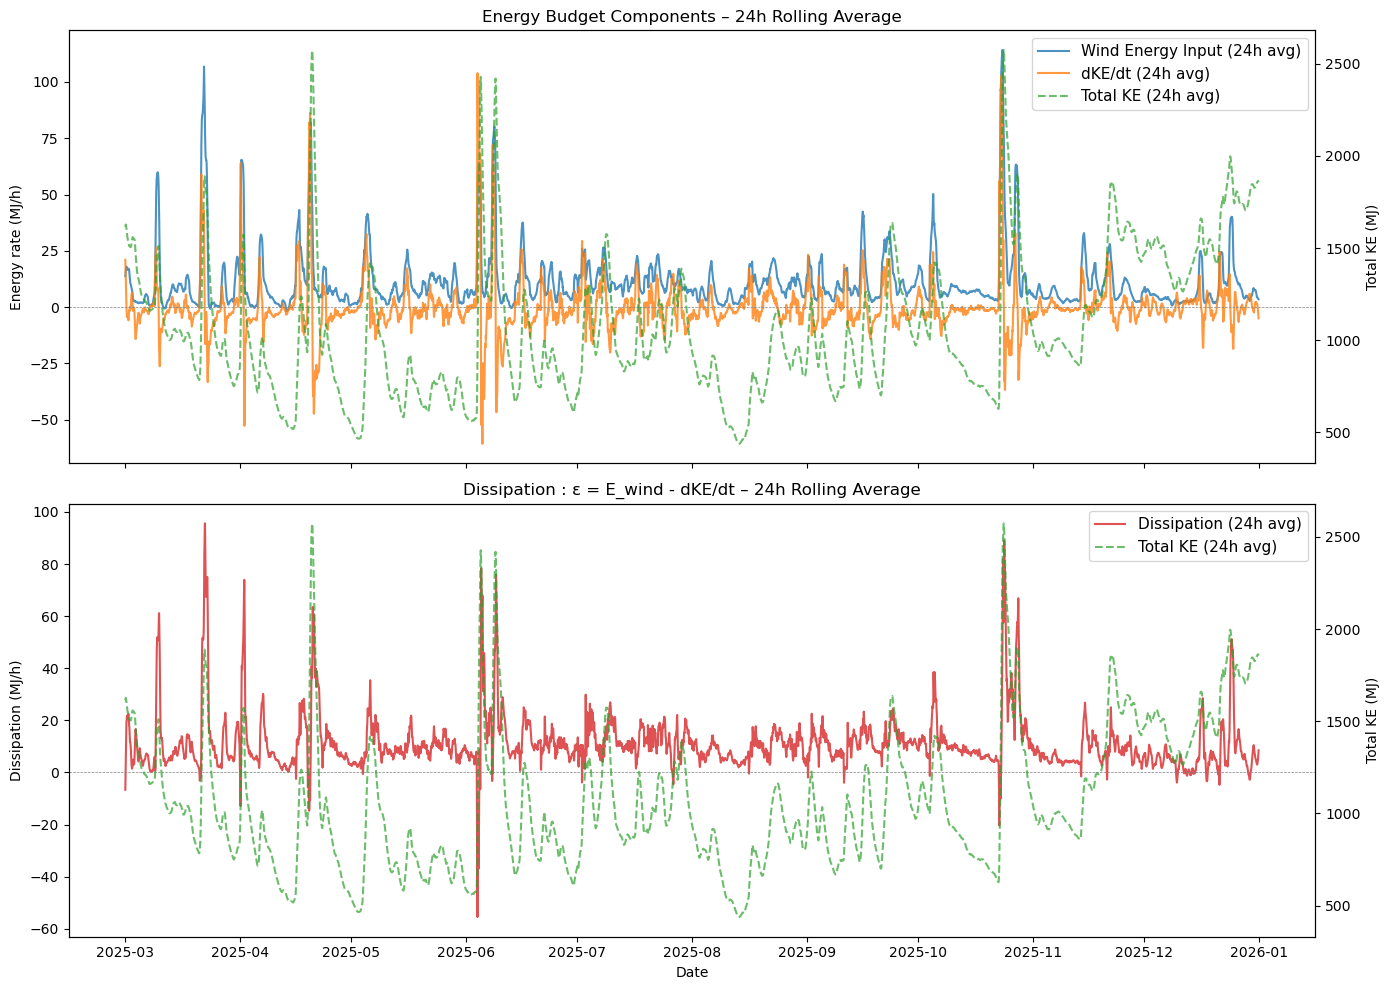

In [72]:
# Compute dissipation rate (epsilon) from the energy budget:
# KE/dt = E_wind_input - epsilon
# => epsilon = E_wind_input - dKE/dtd

# Convert lake_ke index to datetime
lake_ke_ts = lake_ke.copy()
lake_ke_ts.index = pd.to_datetime(lake_ke_ts.index)
lake_ke_ts = lake_ke_ts.sort_index()

# Compute dKE/dt (time derivative of lake kinetic energy) in MJ/h
dt_hours = lake_ke_ts.index.to_series().diff().dt.total_seconds() / 3600.0
dKE_dt = lake_ke_ts['kinetic_energy_[MJ]'].diff() / dt_hours

# Align wind energy input with lake_ke timestamps
E_wind_aligned = E_wind_MJ.sel(time=lake_ke_ts.index, method='nearest')

# Dissipation rate: epsilon = E_wind_input - dKE/dt  [MJ/h]
dissipation = pd.DataFrame({
    'E_wind_input_[MJ/h]': E_wind_aligned.values,
    'dKE_dt_[MJ/h]': dKE_dt.values,
    'dissipation_[MJ/h]': E_wind_aligned.values - dKE_dt.values
}, index=lake_ke_ts.index)
dissipation.index.name = 'date'

# Apply a rolling average
dissipation_rolling = dissipation.rolling(window=rolling_window, center=True, min_periods=1).mean()

# Apply a rolling average on total KE
lake_ke_rolling = lake_ke_ts[['kinetic_energy_[MJ]']].rolling(window=rolling_window, center=True, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top panel: energy budget components
axes[0].plot(dissipation_rolling.index, dissipation_rolling['E_wind_input_[MJ/h]'], label=f'Wind Energy Input ({rolling_window}h avg)',
             alpha=0.8)
axes[0].plot(dissipation_rolling.index, dissipation_rolling['dKE_dt_[MJ/h]'], label=f'dKE/dt ({rolling_window}h avg)', alpha=0.8)
axes[0].set_ylabel('Energy rate (MJ/h)')
axes[0].set_title(f'Energy Budget Components – {rolling_window}h Rolling Average')
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Right axis for total KE on top panel
ax0_right = axes[0].twinx()
ax0_right.plot(lake_ke_rolling.index, lake_ke_rolling['kinetic_energy_[MJ]'], label=f'Total KE ({rolling_window}h avg)', color='C2',
               alpha=0.7, linestyle='--')
ax0_right.set_ylabel('Total KE (MJ)')

# Combine legends from both axes
lines0, labels0 = axes[0].get_legend_handles_labels()
lines0r, labels0r = ax0_right.get_legend_handles_labels()
axes[0].legend(lines0 + lines0r, labels0 + labels0r, fontsize=11)

# Bottom panel: dissipation rate
axes[1].plot(dissipation_rolling.index, dissipation_rolling['dissipation_[MJ/h]'], label=f'Dissipation ({rolling_window}h avg)',
             color='C3',
             alpha=0.8)
axes[1].set_ylabel('Dissipation (MJ/h)')
axes[1].set_xlabel('Date')
axes[1].set_title(f'Dissipation : ε = E_wind - dKE/dt – {rolling_window}h Rolling Average')
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Right axis for total KE on bottom panel
ax1_right = axes[1].twinx()
ax1_right.plot(lake_ke_rolling.index, lake_ke_rolling['kinetic_energy_[MJ]'], label=f'Total KE ({rolling_window}h avg)', color='C2',
               alpha=0.7, linestyle='--')
ax1_right.set_ylabel('Total KE (MJ)')

# Combine legends from both axes
lines1, labels1 = axes[1].get_legend_handles_labels()
lines1r, labels1r = ax1_right.get_legend_handles_labels()
axes[1].legend(lines1 + lines1r, labels1 + labels1r, fontsize=11)

plt.tight_layout()
plt.show()


In [73]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import HoverTool

In [74]:
output_notebook()

# Prepare data
diss_times = dissipation_rolling.index[1:]
diss_values = dissipation_rolling['dissipation_[MJ/h]'].iloc[1:] * 1e6 / total_area / 3600
neg_dKE_dt_values = -dissipation_rolling['dKE_dt_[MJ/h]'].iloc[1:] *1e6 / total_area / 3600

eps = pd.Series(diss_values.values, index=diss_times)
neg_dke = pd.Series(neg_dKE_dt_values.values, index=diss_times)

p = figure(
    title=f'Dissipation Rate (ε = E_wind - dKE/dt) – {rolling_window}h Rolling Average',
    x_axis_type='datetime',
    width=1200,
    height=450,
    x_axis_label='Date',
    y_axis_label='Dissipation (W/m2)',
    tools='xpan,xwheel_zoom,box_zoom,reset,save',
    active_scroll='xwheel_zoom',
)

p.line(diss_times, diss_values, legend_label='Dissipation Rate', line_color='#E45756', line_width=1.5, alpha=0.8)
p.line(diss_times, neg_dKE_dt_values, legend_label='-dKE/dt', line_color='#4C78A8', line_width=1.5, alpha=0.8)

# Zero reference line
p.line(diss_times, [0] * len(diss_times), line_color='gray', line_dash='dashed', line_width=0.5)

p.add_tools(HoverTool(tooltips=[('Date', '@x{%F %H:%M}'), ('Value (W/m2)', '@y{0.2f}')],
                      formatters={'@x': 'datetime'}, mode='vline'))

p.legend.location = 'top_right'
p.legend.click_policy = 'hide'

show(p)


Loading BokehJS ...

In [87]:
def get_linear_trend_curve(x_data, y_data):
    valid = np.isfinite(x_data) & np.isfinite(y_data)
    x = x_data[valid].values
    y = y_data[valid].values

    # --- Linear fit ---
    m, b = np.polyfit(x, y, 1)

    # Trend line
    x_sorted = np.linspace(x.min(), x.max(), 300)
    y_trend = m * x_sorted + b

    # Predictions at original x (for fit metrics)
    y_hat = m * x + b
    resid = y - y_hat

    # --- Fit quality ---
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    return (x_sorted, y_trend), r2, rmse, mae

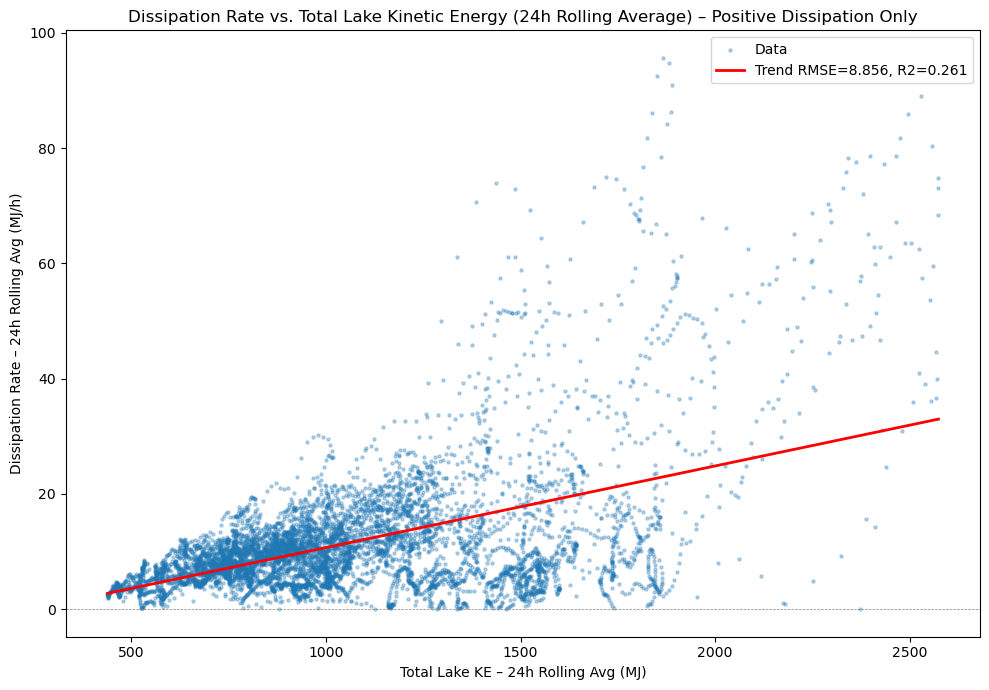

In [93]:
# Filter to only positive dissipation values
positive_mask = dissipation_rolling['dissipation_[MJ/h]'].iloc[1:] > 0

x_data = lake_ke_rolling['kinetic_energy_[MJ]'].iloc[1:][positive_mask]
y_data = dissipation_rolling['dissipation_[MJ/h]'].iloc[1:][positive_mask]

# Fit a linear trend curve
(x_trend, y_trend), r2, rmse, mae = get_linear_trend_curve(x_data, y_data)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    x_data,
    y_data,
    s=5, alpha=0.3, label='Data'
)
ax.plot(x_trend, y_trend, color='red', linewidth=2, label=f'Trend RMSE={rmse:.3f}, R2={r2:.3f}')
ax.set_xlabel(f'Total Lake KE – {rolling_window}h Rolling Avg (MJ)')
ax.set_ylabel(f'Dissipation Rate – {rolling_window}h Rolling Avg (MJ/h)')
ax.set_title(f'Dissipation Rate vs. Total Lake Kinetic Energy ({rolling_window}h Rolling Average) – Positive Dissipation Only')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()


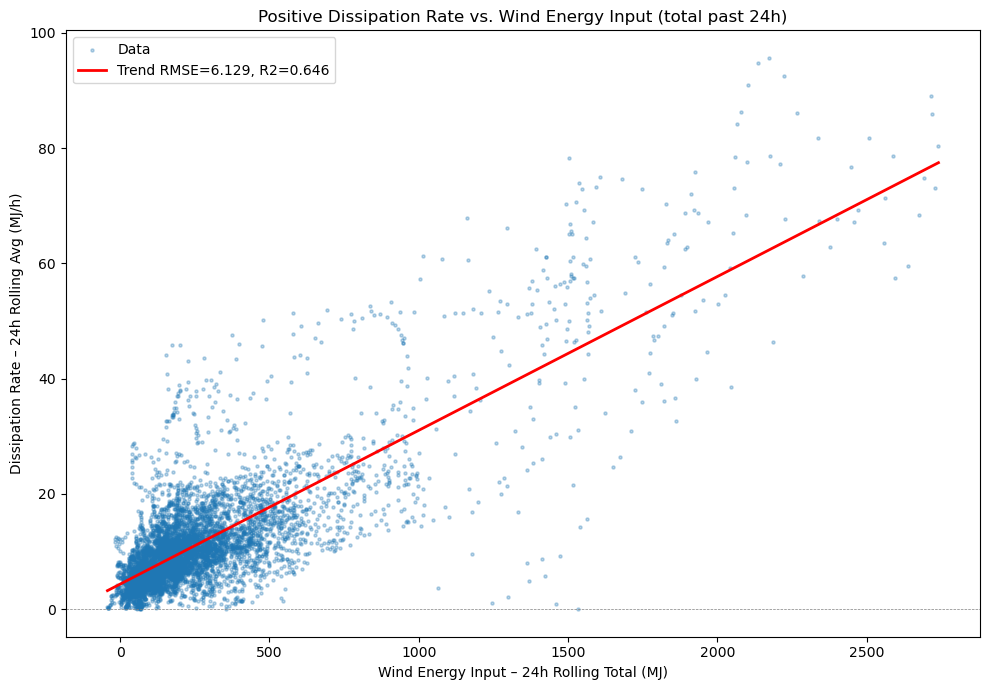

In [92]:
E_wind_MJ_24h_sum = E_wind_MJ.rolling(time=rolling_window, min_periods=1).sum()
E_wind_24h_sum_aligned = E_wind_MJ_24h_sum.sel(time=lake_ke_ts.index, method='nearest')

positive_mask = dissipation_rolling['dissipation_[MJ/h]'].iloc[1:] > 0

x_neg = pd.Series(E_wind_24h_sum_aligned.values[1:], index=dissipation_rolling.index[1:])[positive_mask]
y_neg = dissipation_rolling['dissipation_[MJ/h]'].iloc[1:][positive_mask]

# Fit a linear trend curve
(x_trend, y_trend), r2, rmse, mae = get_linear_trend_curve(x_neg, y_neg)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(x_neg, y_neg, s=5, alpha=0.3, label='Data')
ax.plot(x_trend, y_trend, color='red', linewidth=2, label=f'Trend RMSE={rmse:.3f}, R2={r2:.3f}')
ax.set_xlabel(f'Wind Energy Input – {rolling_window}h Rolling Total (MJ)')
ax.set_ylabel(f'Dissipation Rate – {rolling_window}h Rolling Avg (MJ/h)')
ax.set_title(f'Positive Dissipation Rate vs. Wind Energy Input (total past {rolling_window}h)')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()


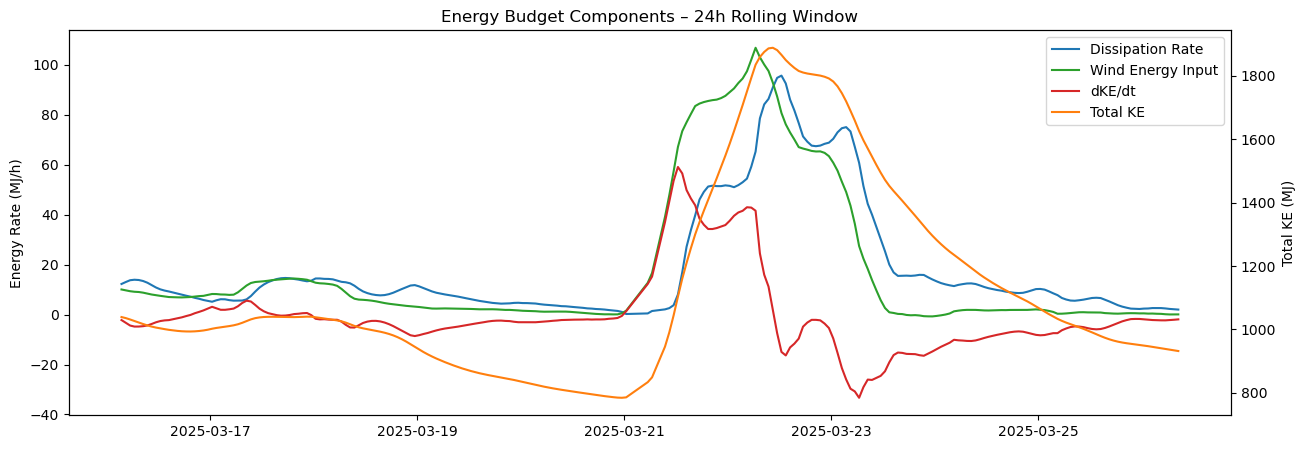

In [79]:
fig, ax1 = plt.subplots(figsize=(15, 5))
i_start = 24 * 15
ax1.plot(y_data[i_start:i_start + 24 * 10], label='Dissipation Rate')
ax2 = ax1.twinx()
ax2.plot(x_data[i_start:i_start + 24 * 10], color='C1', label='Total KE')

# Add wind energy on the left axis
E_wind_rolling_aligned = dissipation_rolling['E_wind_input_[MJ/h]'].iloc[1:][positive_mask]
ax1.plot(E_wind_rolling_aligned[i_start:i_start + 24 * 10], color='C2', label='Wind Energy Input')

# Add dKE/dt on the left axis
dKE_dt_rolling_aligned = dissipation_rolling['dKE_dt_[MJ/h]'].iloc[1:][positive_mask]
ax1.plot(dKE_dt_rolling_aligned[i_start:i_start + 24 * 10], color='C3', label='dKE/dt')

# Add title with rolling window
ax1.set_title(f'Energy Budget Components – {rolling_window}h Rolling Window')

# Add y-axis labels
ax1.set_ylabel('Energy Rate (MJ/h)')
ax2.set_ylabel('Total KE (MJ)')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)


# Check energy spectrum to see if we can easily remove IW influence

In [ ]:
from utils_signal_processing import *

In [ ]:
xr_diss = dissipation_rolling.to_xarray()

In [ ]:
ke_fft = xr_compute_meanfft(xr_diss['dissipation_[MJ/h]'].rename({'date':'time'}), M=1)

In [ ]:
cutoff1_hr = 138
cutoff2_hr = 3

cutoff1 = 1/(cutoff1_hr * 3600)
cutoff2 = 1/(cutoff2_hr * 3600)

In [ ]:
fig,ax = plot_freq_spectrum(ke_fft, 'KE', depth=0, m_segm=1, y_lim_min=1e-7, x_lim_min=1e-8, fontsize=10)
ax.axvline(x = cutoff1, linestyle="--", color="k",label="cutoff1")
ax.axvline(x = cutoff2, linestyle="--", color="k",label="cutoff2")
ax.legend()